In [ ]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

In [1]:
import tensorflow as tf
import tensorflow.keras as keras
from tensorflow.keras import callbacks
from tensorflow.keras.layers import Dense,GlobalAveragePooling2D
from tensorflow.keras.metrics import Precision, Recall

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

2024-03-17 22:49:38.633214: E external/local_xla/xla/stream_executor/cuda/cuda_dnn.cc:9261] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2024-03-17 22:49:38.633329: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:607] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2024-03-17 22:49:38.770846: E external/local_xla/xla/stream_executor/cuda/cuda_blas.cc:1515] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


In [2]:
data_dir = "/kaggle/input/multiple-sclerosis/Multiple Sclerosis"

resize_size = (240,240)

batch_size = 32

In [3]:
#train_data 
full_data = tf.keras.preprocessing.image_dataset_from_directory(
    directory = data_dir ,
    image_size = resize_size ,
    label_mode = "categorical" ,
    batch_size = batch_size 
    )

#Classes Names
class_names= full_data.class_names
class_names

Found 3427 files belonging to 4 classes.


['Control-Axial', 'Control-Sagittal', 'MS-Axial', 'MS-Sagittal']

In [4]:
def showSampleImages(data):
    class_names=data.class_names
    plt.figure(figsize=(12, 12))
    for images,labels in data.take(1):
        for i in range(9):
            ax = plt.subplot(3, 3, i + 1)
            plt.imshow(images[i].numpy().astype("uint8"))
            plt.title(class_names[tf.argmax(labels[i])])
            plt.axis("off")

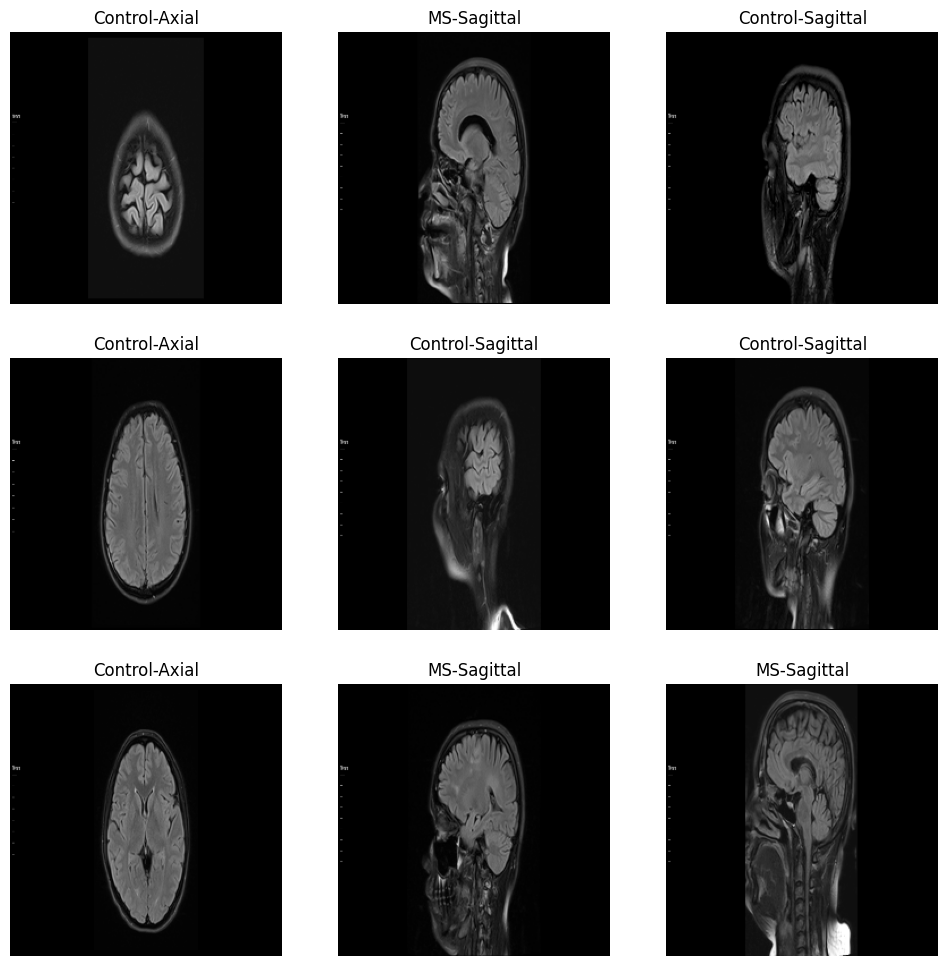

In [5]:
showSampleImages(full_data)

<h1 style="color:red">Checking wheather the data is imbalanced</h1>

In [33]:
def print_count_and_bar_graph(data,data_name,pallete_style="deep"):
    class_names=data.class_names
    ds=pd.DataFrame({'Class':class_names,'Count':len(class_names)*[0]})
    
    #Looping over the data
    for images,labels in data:
        for i in range(len(images)):
            for category in class_names:
                if class_names[tf.argmax(labels[i])]==category:
                    ds.loc[ds['Class']==category,'Count']+=1
    #print count
    for category in class_names:
        print(f"{category} : {ds.loc[ds['Class']==category,'Count']}")

    #print bar plot
    plt.figure(figsize=(12,7))
    ax = sns.barplot(data=ds , x='Class',y='Count', palette=pallete_style)
    sns.set(style="dark",palette="colorblind")
    plt.title('Count of images in each class of '+data_name, fontsize=20)
    ax.bar_label(ax.containers[0])
    plt.show()


Control-Axial : 0    1002
Name: Count, dtype: int64
Control-Sagittal : 1    1014
Name: Count, dtype: int64
MS-Axial : 2    650
Name: Count, dtype: int64
MS-Sagittal : 3    761
Name: Count, dtype: int64


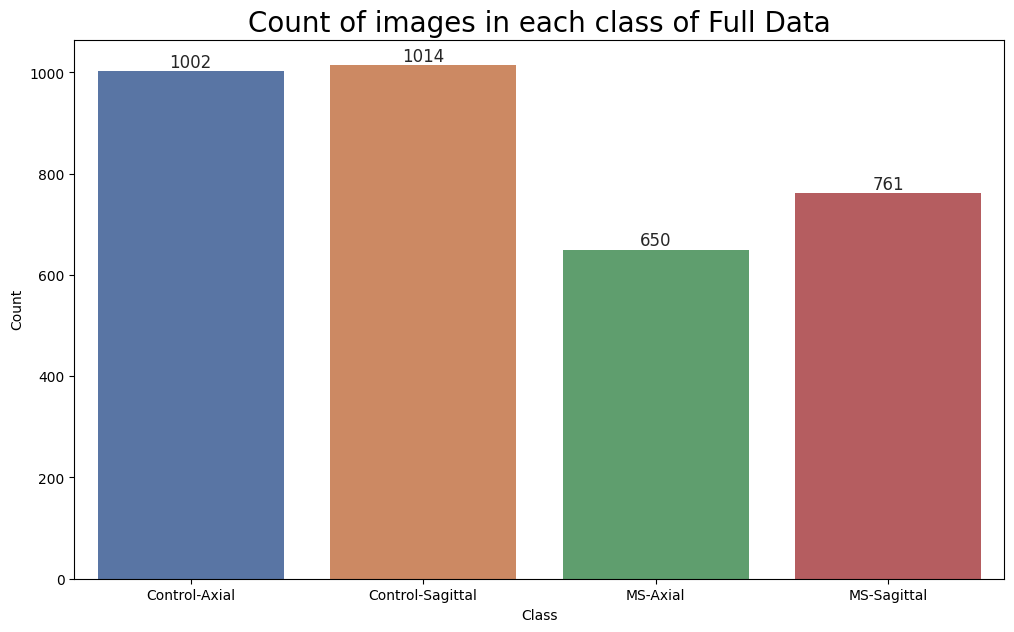

In [7]:
print_count_and_bar_graph(full_data,"Full Data")

<h3 style="color:blue">As we can see data is not balanaced.Two classes have  less data</h3>
*  MS-Axial = 650
* MS-Sagittal = 761

<h1 style="color:Green">Genererating new data using Augmentation</h1>

In [8]:
import os
from tensorflow.keras.preprocessing.image import ImageDataGenerator

def GenerateNewData(data_dir_path, save_dir, class_name, num_images_to_generate):
    data = tf.keras.preprocessing.image_dataset_from_directory(
        data_dir_path,
        image_size=resize_size,
        batch_size=batch_size,
        label_mode=None  # No labels, all images belong to the same class
    )

    datagen = ImageDataGenerator(
        rotation_range=20,
        width_shift_range=0.2,
        height_shift_range=0.2,
        shear_range=0.2,
        zoom_range=0.2,
        horizontal_flip=True,
        fill_mode='nearest'
    )

    if not os.path.exists(save_dir):
        os.makedirs(save_dir)

    num_generated_images = 0

    for images in data:
        # Generate augmented images for the entire batch
        augmented_batch = datagen.flow(images, batch_size=batch_size)

        # Save augmented images until the desired count is reached
        for augmented_images in augmented_batch:
            for augmented_image in augmented_images:
                tf.keras.preprocessing.image.save_img(
                    os.path.join(save_dir, f"augmented_image_{num_generated_images}.png"),
                    augmented_image
                )
                num_generated_images += 1
                if num_generated_images >= num_images_to_generate:
                    break
            if num_generated_images >= num_images_to_generate:
                break
        if num_generated_images >= num_images_to_generate:
            break

    print("Generated and saved", num_generated_images, class_name + " data images.")


In [9]:
GenerateNewData("/kaggle/input/multiple-sclerosis/Multiple Sclerosis/MS-Axial","MS-Axial","MS-Axial",1014-650)

Found 650 files.
Generated and saved 364 MS-Axial data images.


In [10]:
GenerateNewData("/kaggle/input/multiple-sclerosis/Multiple Sclerosis/MS-Sagittal","MS-Sagittal","MS-Sagittal",1014-761)

Found 761 files.
Generated and saved 253 MS-Sagittal data images.


In [11]:
class_names = full_data.class_names

# Create the directory structure
for class_name in class_names:
    os.makedirs(class_name, exist_ok=True)

In [ ]:

# Iterate over the dataset and save images
batch_no=0
for images, labels in full_data:
    for i in range(len(images)):
        image = images[i].numpy()
        label = labels[i].numpy()
        class_name = class_names[label.argmax()]
        
        # Save image with class name as directory name
        image_filename = f"image_{batch_no}{i}.png"
        save_path = os.path.join(class_name, image_filename)
        tf.keras.preprocessing.image.save_img(save_path, image)
    batch_no+=1

    print("Saved images to new directory")


In [13]:
os.listdir("/kaggle/working/")

['Control-Axial',
 'MS-Axial',
 'MS-Sagittal',
 '.virtual_documents',
 'Control-Sagittal']

In [14]:
os.rmdir("/kaggle/working/.virtual_documents")

In [15]:
os.listdir("/kaggle/working/")

['Control-Axial', 'MS-Axial', 'MS-Sagittal', 'Control-Sagittal']

In [16]:
full_data = tf.keras.preprocessing.image_dataset_from_directory(
    directory = "/kaggle/working/" ,
    image_size = resize_size ,
    label_mode = "categorical" ,
    batch_size = batch_size 
    )

#Classes Names
class_names= full_data.class_names
class_names

Found 3993 files belonging to 4 classes.


['Control-Axial', 'Control-Sagittal', 'MS-Axial', 'MS-Sagittal']

Control-Axial : 0    988
Name: Count, dtype: int64
Control-Sagittal : 1    997
Name: Count, dtype: int64
MS-Axial : 2    1007
Name: Count, dtype: int64
MS-Sagittal : 3    1001
Name: Count, dtype: int64


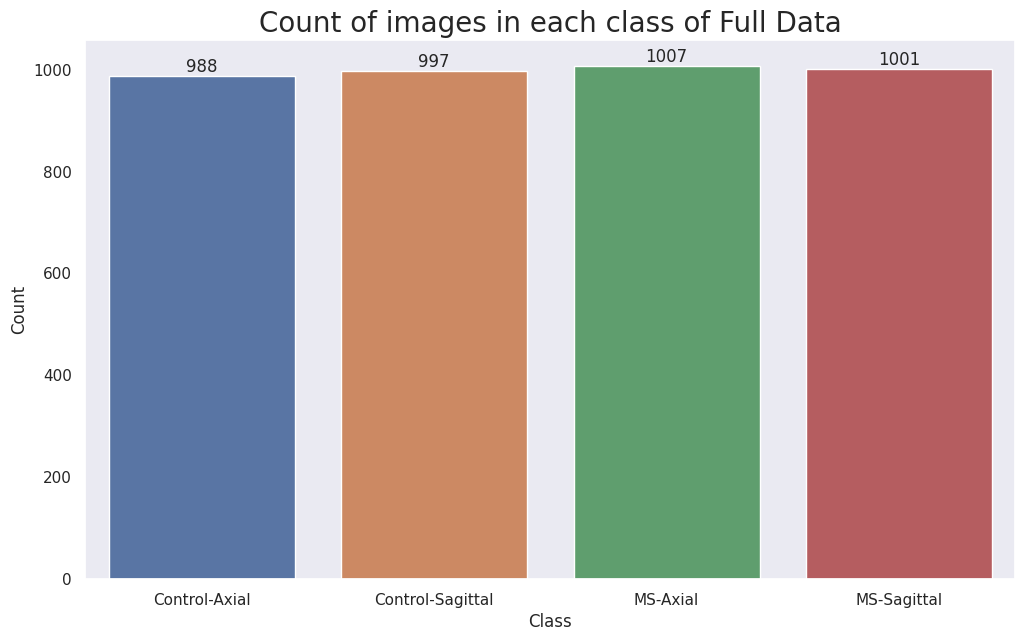

In [18]:
print_count_and_bar_graph(full_data,"Full Data")

<h2 style="color:blue">Data is balanced now</h2>

In [30]:
import shutil
import random

data_dir = '/kaggle/working/'

train_dir = 'train'
test_dir = 'test'

# Creating train and test directories if they don't exist
os.makedirs(train_dir, exist_ok=True)
os.makedirs(test_dir, exist_ok=True)


subdirs = ['Control-Axial', 'Control-Sagittal', 'MS-Axial', 'MS-Sagittal']

for subdir in subdirs:
    # Creating subdirectories in train and test directories
    os.makedirs(os.path.join(train_dir, subdir), exist_ok=True)
    os.makedirs(os.path.join(test_dir, subdir), exist_ok=True)
    
    # List all files in the current subdirectory
    files = os.listdir(os.path.join(data_dir, subdir))
    
    # Shuffle the files randomly
    random.shuffle(files)
    
    # Calculate the number of files to move to the train directory (90%)
    num_train = int(0.9 * len(files))
    
    # Move files to the train directory
    for file in files[:num_train]:
        src = os.path.join(data_dir, subdir, file)
        dst = os.path.join(train_dir, subdir, file)
        shutil.copy(src, dst)
    
    # Move remaining files to the test directory
    for file in files[num_train:]:
        src = os.path.join(data_dir, subdir, file)
        dst = os.path.join(test_dir, subdir, file)
        shutil.copy(src, dst)

print("Data split into train and test directories successfully.")


Data split into train and test directories successfully.


In [40]:
train_dir="/kaggle/working/train"
train_data = tf.keras.preprocessing.image_dataset_from_directory(
    directory=train_dir,
    image_size=resize_size,
    label_mode="categorical",
    batch_size=batch_size,
    validation_split=0.1,  # 10% for validation
    subset="training",
    seed=123
)


#validation dataset
val_data = tf.keras.preprocessing.image_dataset_from_directory(
    directory=train_dir,
    image_size=resize_size,
    label_mode="categorical",
    batch_size=batch_size,
    validation_split=0.1,  # 10% for validation
    subset="validation",
    seed=123
)

Found 3592 files belonging to 4 classes.
Using 3233 files for training.
Found 3592 files belonging to 4 classes.
Using 359 files for validation.


In [41]:
test_dir="/kaggle/working/test"
test_data = tf.keras.preprocessing.image_dataset_from_directory(
    directory = test_dir ,
    image_size = resize_size ,
    label_mode = "categorical" ,
    batch_size = batch_size ,
    )


Found 401 files belonging to 4 classes.


# Ckecking Count of data

Control-Axial : 0    798
Name: Count, dtype: int64
Control-Sagittal : 1    813
Name: Count, dtype: int64
MS-Axial : 2    807
Name: Count, dtype: int64
MS-Sagittal : 3    815
Name: Count, dtype: int64


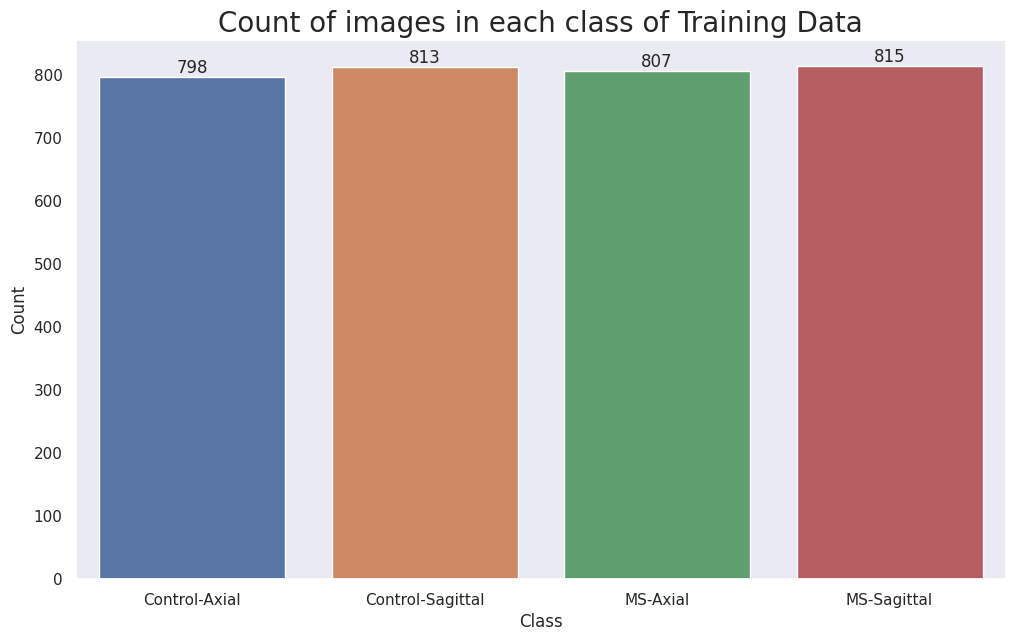

In [42]:
print_count_and_bar_graph(train_data,"Training Data")

Control-Axial : 0    91
Name: Count, dtype: int64
Control-Sagittal : 1    84
Name: Count, dtype: int64
MS-Axial : 2    99
Name: Count, dtype: int64
MS-Sagittal : 3    85
Name: Count, dtype: int64


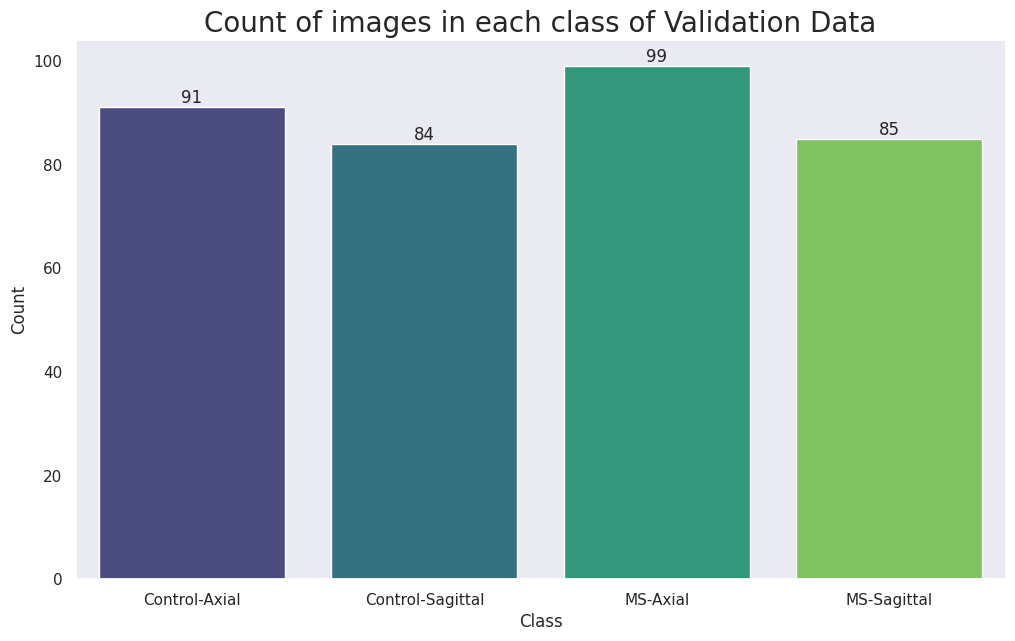

In [43]:
print_count_and_bar_graph(val_data,"Validation Data",pallete_style="viridis")

Control-Axial : 0    99
Name: Count, dtype: int64
Control-Sagittal : 1    100
Name: Count, dtype: int64
MS-Axial : 2    101
Name: Count, dtype: int64
MS-Sagittal : 3    101
Name: Count, dtype: int64


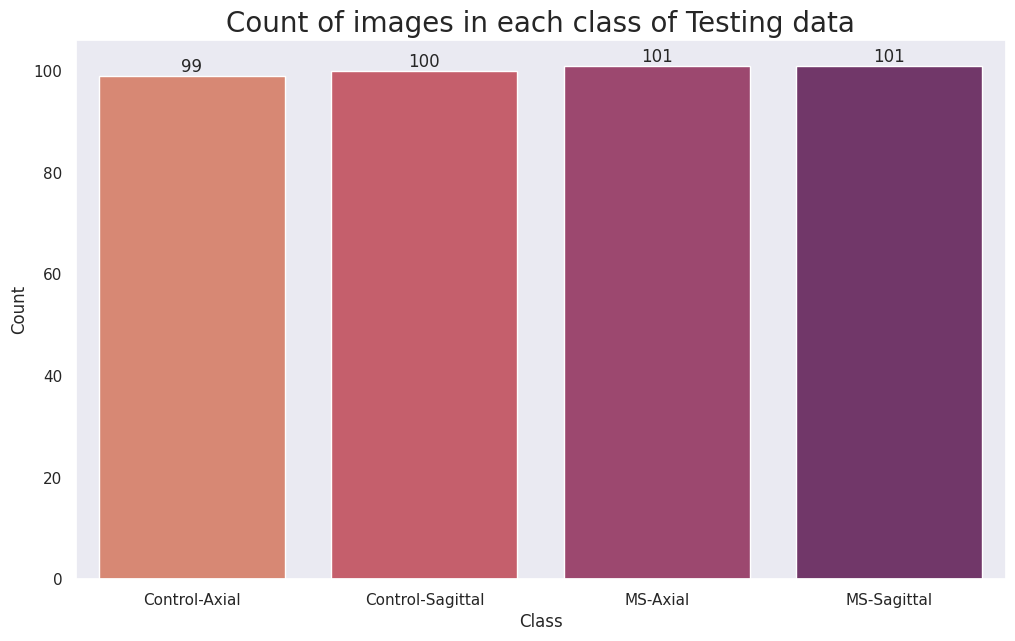

In [44]:
print_count_and_bar_graph(test_data,"Testing data",pallete_style="flare")

In [45]:
img_shape=(240,240,3)
base_model = tf.keras.applications.Xception(include_top= False, weights= "imagenet",
                            input_shape= img_shape, pooling= 'max')

83683744/83683744 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


In [47]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Flatten
from tensorflow.keras.optimizers import Adamax
from tensorflow.keras.metrics import Precision, Recall
from tensorflow.keras.models import Model

In [50]:
x=base_model.output
x=Dropout(rate= 0.3)(x)
x=Dense(128, activation= 'relu')(x)
x=Dropout(rate= 0.25)(x)
x =Dense(4, activation="softmax")(x)

model = Model(base_model.input, x)


In [51]:
model.summary()

Model: "functional_3"

┏━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━┓
┃ Layer (type)        ┃ Output Shape      ┃    Param # ┃ Connected to      ┃
┡━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━┩
│ input_layer         │ (None, 240, 240,  │          0 │ -                 │
│ (InputLayer)        │ 3)                │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1        │ (None, 119, 119,  │        864 │ input_layer[0][0] │
│ (Conv2D)            │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_bn     │ (None, 119, 119,  │        128 │ block1_conv1[0][… │
│ (BatchNormalizatio… │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv1_act    │ (None, 119, 119,  │          0 │ block1_conv1_bn[… │
│ (Activation)        │ 32)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2        │ (None, 117, 117,  │     18,432 │ block1_conv1_act… │
│ (Conv2D)            │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_bn     │ (None, 117, 117,  │        256 │ block1_conv2[0][… │
│ (BatchNormalizatio… │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block1_conv2_act    │ (None, 117, 117,  │          0 │ block1_conv2_bn[… │
│ (Activation)        │ 64)               │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1     │ (None, 117, 117,  │      8,768 │ block1_conv2_act… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv1_bn  │ (None, 117, 117,  │        512 │ block2_sepconv1[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_act │ (None, 117, 117,  │          0 │ block2_sepconv1_… │
│ (Activation)        │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2     │ (None, 117, 117,  │     17,536 │ block2_sepconv2_… │
│ (SeparableConv2D)   │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_sepconv2_bn  │ (None, 117, 117,  │        512 │ block2_sepconv2[… │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ conv2d (Conv2D)     │ (None, 59, 59,    │      8,192 │ block1_conv2_act… │
│                     │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block2_pool         │ (None, 59, 59,    │          0 │ block2_sepconv2_… │
│ (MaxPooling2D)      │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ batch_normalization │ (None, 59, 59,    │        512 │ conv2d[0][0]      │
│ (BatchNormalizatio… │ 128)              │            │                   │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ add (Add)           │ (None, 59, 59,    │          0 │ block2_pool[0][0… │
│                     │ 128)              │            │ batch_normalizat… │
├─────────────────────┼───────────────────┼────────────┼───────────────────┤
│ block3_sepconv1_act │ (None, 59, 59,    │          0 │ add[0][0]       

 Total params: 21,124,268 (80.58 MB)

 Trainable params: 21,069,740 (80.37 MB)

 Non-trainable params: 54,528 (213.00 KB)

In [52]:
callback_list=[
    callbacks.EarlyStopping(monitor="val_accuracy",patience=3,restore_best_weights=True),
    callbacks.EarlyStopping(monitor="val_loss",patience=3,restore_best_weights=True),
    callbacks.ReduceLROnPlateau(factor=0.8,monitor="val_accuracy",patience=3)
]

In [53]:
 model.compile(loss = "categorical_crossentropy", 
                  optimizer = Adamax(learning_rate= 0.001),
                  metrics=['accuracy', Precision(), Recall()])
    

In [54]:
Model_History= model.fit(train_data,
                 epochs=10,
                 validation_data=val_data,
                 verbose = 1 ,
                 callbacks = callback_list,
                 shuffle= False)

Epoch 1/10


I0000 00:00:1710718110.882271     110 device_compiler.h:186] Compiled cluster using XLA!  This line is logged at most once for the lifetime of the process.
W0000 00:00:1710718110.962371     110 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


102/102 ━━━━━━━━━━━━━━━━━━━━ 0s 512ms/step - accuracy: 0.6575 - loss: 0.8905 - precision: 0.7049 - recall: 0.5156

W0000 00:00:1710718166.498736     109 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


102/102 ━━━━━━━━━━━━━━━━━━━━ 127s 601ms/step - accuracy: 0.6588 - loss: 0.8871 - precision: 0.7061 - recall: 0.5177 - val_accuracy: 0.8189 - val_loss: 0.4637 - val_precision: 0.8184 - val_recall: 0.8162 - learning_rate: 0.0010
Epoch 2/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 32s 308ms/step - accuracy: 0.9310 - loss: 0.2004 - precision: 0.9327 - recall: 0.9293 - val_accuracy: 0.8997 - val_loss: 0.2539 - val_precision: 0.8997 - val_recall: 0.8997 - learning_rate: 0.0010
Epoch 3/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 32s 308ms/step - accuracy: 0.9552 - loss: 0.1169 - precision: 0.9561 - recall: 0.9541 - val_accuracy: 0.9415 - val_loss: 0.1670 - val_precision: 0.9415 - val_recall: 0.9415 - learning_rate: 0.0010
Epoch 4/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 31s 307ms/step - accuracy: 0.9746 - loss: 0.0765 - precision: 0.9762 - recall: 0.9738 - val_accuracy: 0.9471 - val_loss: 0.2211 - val_precision: 0.9471 - val_recall: 0.9471 - learning_rate: 0.0010
Epoch 5/10
102/102 ━━━━━━━━━━━━━━━━━━━━ 31s 307ms/step - accur

In [55]:
def plot_metrices_graphs(Model_History, start=0):
    metrices = {
        "train_Loss": Model_History.history['loss'],
        "val_Loss": Model_History.history['val_loss'],
        "train_Accuracy": Model_History.history['accuracy'],
        "val_Accuracy": Model_History.history['val_accuracy'],
        "train_Precision": Model_History.history['precision'],
        "val_Precision": Model_History.history['val_precision'],
        "train_Recall": Model_History.history['recall'],
        "val_Recall": Model_History.history['val_recall']
    }

    bestEpoch = {
        "Loss": np.argmin(metrices["val_Loss"]),
        "Accuracy": np.argmax(metrices["val_Accuracy"]),
        "Precision": np.argmax(metrices["val_Precision"]),
        "Recall": np.argmax(metrices["val_Recall"])
    }

    Epochs = [i + 1 for i in range(start, len(metrices['train_Accuracy']))]

    plt.figure(figsize=(20, 12))
    plt.style.use('fivethirtyeight')

    i = 0
    for j in range(0, 4):
        plt.subplot(2, 2, j+1)
        plt.plot(Epochs, metrices["train_" + list(bestEpoch.keys())[j]], 'r', label=f'Training {list(bestEpoch.keys())[j]}')
        plt.plot(Epochs, metrices["val_" + list(bestEpoch.keys())[j]], 'g', label=f'Validation {list(bestEpoch.keys())[j]}')
        plt.scatter(bestEpoch[list(bestEpoch.keys())[j]], metrices["val_" + list(bestEpoch.keys())[j]][bestEpoch[list(bestEpoch.keys())[j]]], s=150, c='blue', label=f'Best Epoch = {bestEpoch[list(bestEpoch.keys())[j]]}')
        plt.title(f'Training and Validation {list(bestEpoch.keys())[j]}')
        plt.xlabel('Epochs')
        plt.ylabel(f'{list(bestEpoch.keys())[j]}')
        plt.legend()
        plt.grid(True)
        i += 1

    plt.tight_layout()
    plt.subplots_adjust(hspace=0.5, wspace=0.5)
    plt.show()


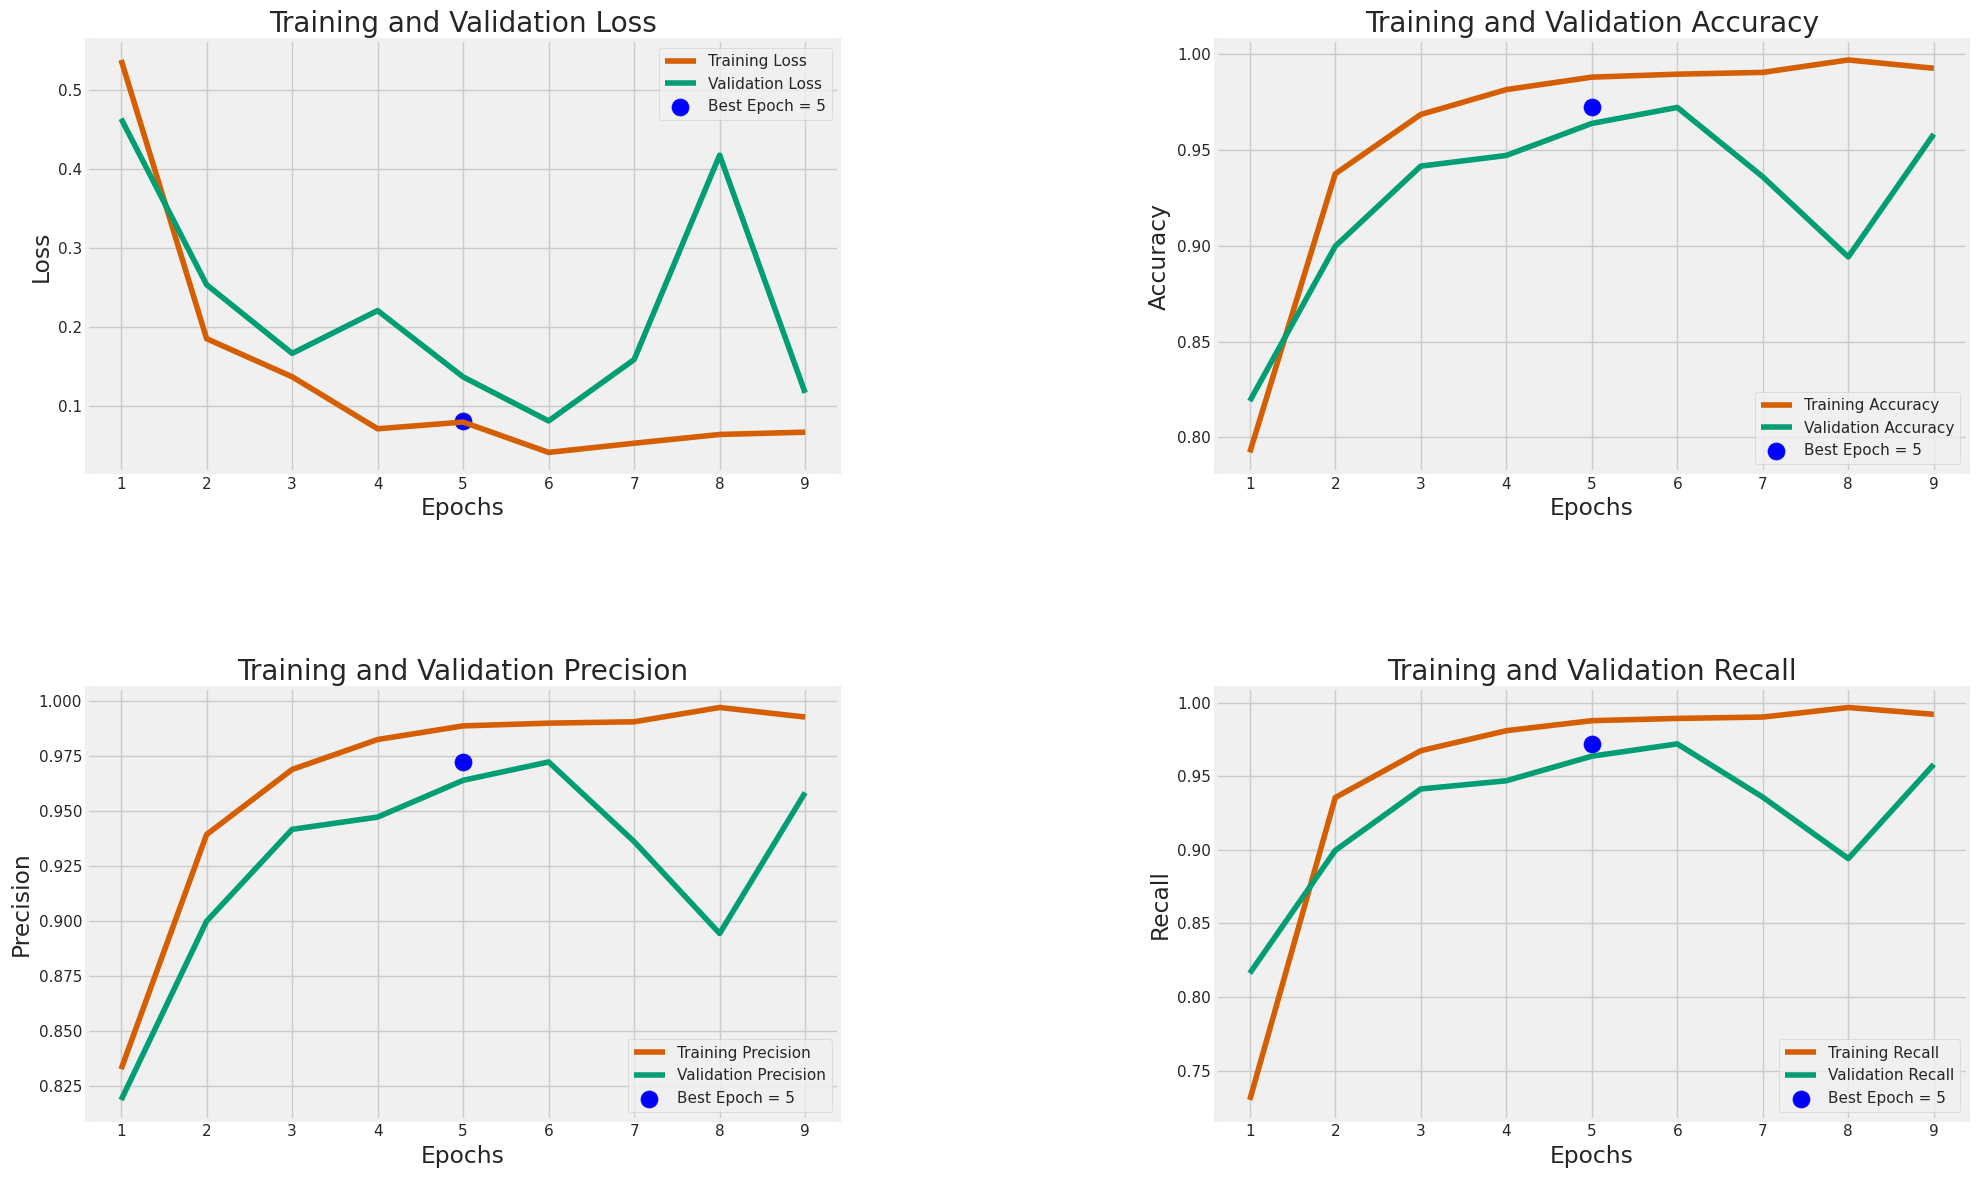

In [56]:
plot_metrices_graphs(Model_History)

In [57]:
def Evaluate_Model(model,train_data,test_data):
    train_score = model.evaluate(train_data, verbose=1)
    test_score = model.evaluate(test_data,verbose=1)

    print(f"Train Loss: {train_score[0]:.4f}")
    print(f"Train Accuracy: {train_score[1]*100:.2f}%")
    print('-' * 30)
    print(f"Test Loss: {test_score[0]:.4f}")
    print(f"Test Accuracy: {test_score[1]*100:.2f}%")

In [58]:
Evaluate_Model(model,train_data,test_data)

102/102 ━━━━━━━━━━━━━━━━━━━━ 11s 107ms/step - accuracy: 0.9993 - loss: 0.0033 - precision: 0.9993 - recall: 0.9993
13/13 ━━━━━━━━━━━━━━━━━━━━ 7s 561ms/step - accuracy: 0.9541 - loss: 0.2091 - precision: 0.9541 - recall: 0.9541
Train Loss: 0.0034
Train Accuracy: 99.88%
------------------------------
Test Loss: 0.1525
Test Accuracy: 96.76%


In [59]:
from sklearn.metrics import classification_report, confusion_matrix

def printClassificationReportAndConfusionMaxtrix(model, class_names, data):
    true_labels = []
    predicted_labels = []

    for images, labels in data:
        true_labels.extend(np.argmax(labels.numpy(),axis=1))  # Convert one-hot encoded labels to class indices
        predicted_labels.extend(np.argmax(model.predict(images),axis=1))  # Obtain model predictions

    # Print classification report
    print("\n" * 5)
    print(classification_report(true_labels, predicted_labels, target_names=class_names))
    print("\n" * 5)

    # Compute the confusion matrix
    conf_matrix = confusion_matrix(true_labels, predicted_labels)

    # Plot the confusion matrix
    plt.figure(figsize=(10, 8))
    sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', xticklabels=class_names, yticklabels=class_names)
    plt.xlabel('Predicted Labels')
    plt.ylabel('True Labels')
    plt.title('Confusion Matrix')
    plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step


W0000 00:00:1710718535.231051     108 graph_launch.cc:671] Fallback to op-by-op mode because memset node breaks graph update


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 42ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 31ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 30ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step






                  precision    recall  f1-score   support

   Control-Axial       0.99      0.98      0.98        99
Control-Sagittal       0.92      0.98      0.95       100
        MS-Axial       0.98      0.99      0.99       101
     MS-Sagittal       0.98      0.92      0.95       101

        accuracy                           0.97       401
       macro avg       0.97      0.97      0.97       401
    weighted avg       0.97      0.97      0.97       401









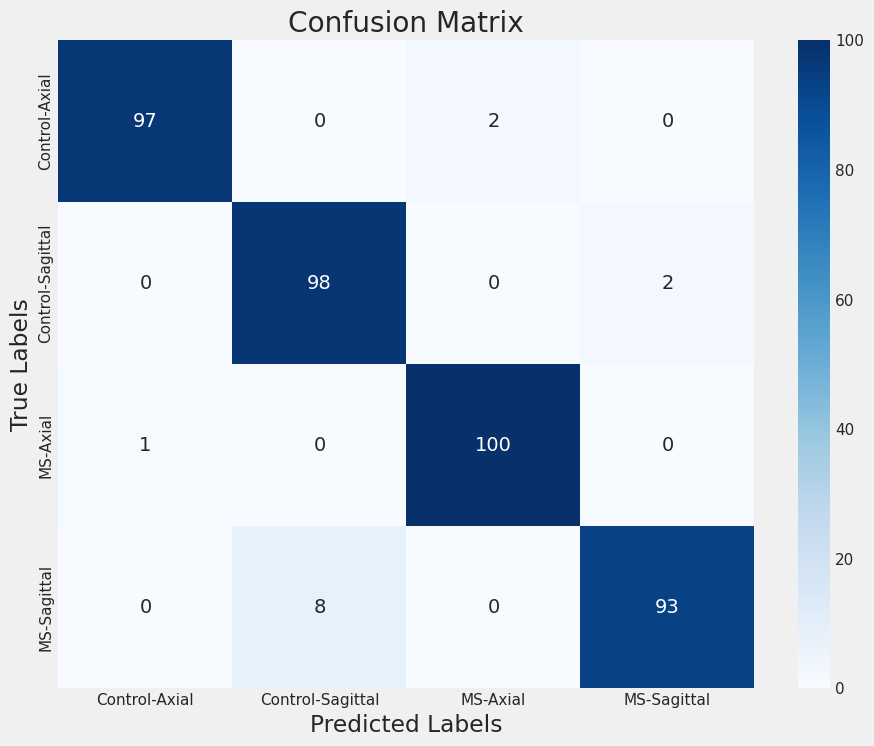

In [60]:
printClassificationReportAndConfusionMaxtrix(model,class_names,test_data)

In [61]:
model.save("MS_xception.h5")

In [62]:
import cv2
from PIL import Image
import scipy  #Used to upsample our image
from matplotlib.patches import Rectangle #To add a rectangle overlay to the image
from skimage.feature.peak import peak_local_max  #To detect hotspots in 2D images. 

In [63]:
def getImage(img_path):
    image = cv2.imread(img_path)
    image = Image.fromarray(image, 'RGB')
    image = image.resize(resize_size)
    image = np.array(image)
    return image

In [64]:
def showPredictionStatistics(img_path,class_names=class_names,size=resize_size):
    plt.figure(figsize=(6, 6))
    img=getImage(img_path)
    predictions = model.predict(np.expand_dims(img, axis=0))
    probs = list(predictions[0]*100)
    print(probs)
    labels = class_names
    plt.subplot(2, 1, 1)
    plt.imshow(img)
    plt.subplot(2, 1, 2)
    bars = plt.barh(labels, probs)
    plt.xlabel('Percentage', fontsize=20)
    ax = plt.gca()
    ax.bar_label(bars, fmt = '%.2f')
    plt.show()

1/1 ━━━━━━━━━━━━━━━━━━━━ 3s 3s/step
[30.45235, 0.44119218, 68.79344, 0.3130225]


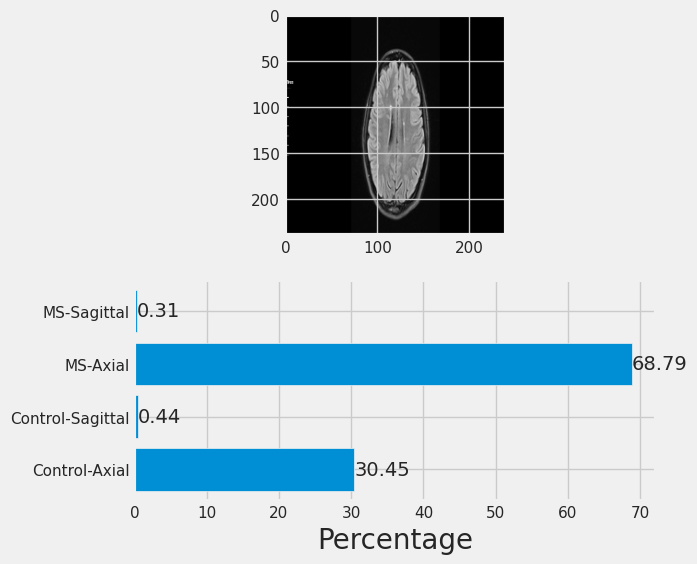

In [65]:
showPredictionStatistics('/kaggle/working/test/MS-Axial/image_965.png')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
[99.91568, 0.0004199075, 0.08383931, 5.7288275e-05]


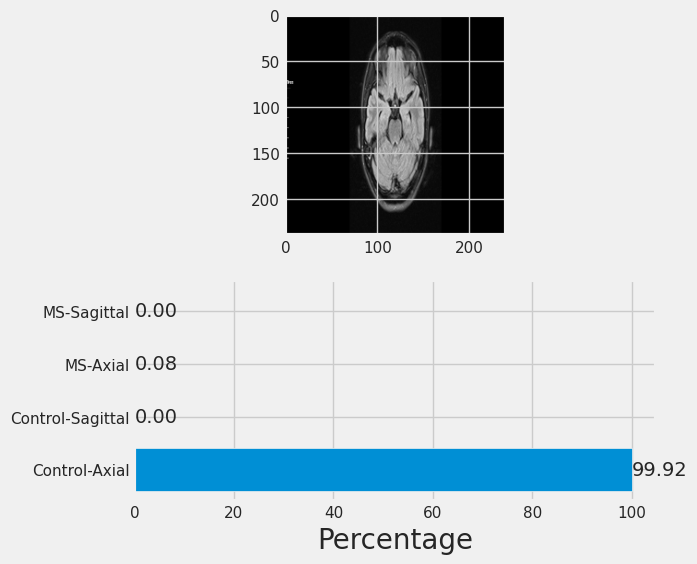

In [66]:
showPredictionStatistics('/kaggle/working/test/Control-Axial/image_6810.png')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
[2.5416478e-08, 0.00015604154, 6.1182463e-06, 99.99983]


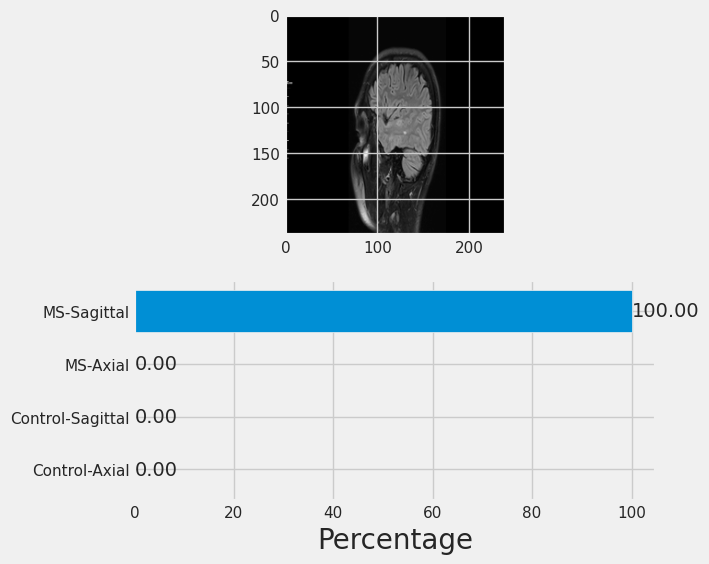

In [67]:
showPredictionStatistics('/kaggle/working/test/MS-Sagittal/image_978.png')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 21ms/step
[2.6504322e-05, 99.997665, 4.4979824e-06, 0.00230198]


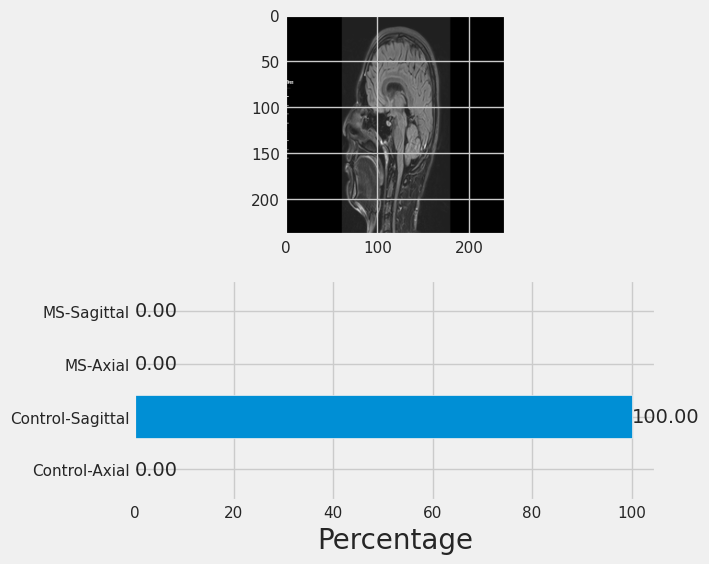

In [68]:
showPredictionStatistics('/kaggle/working/test/Control-Sagittal/image_2525.png')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 20ms/step
[0.0036959932, 0.00016460942, 99.99008, 0.0060516354]


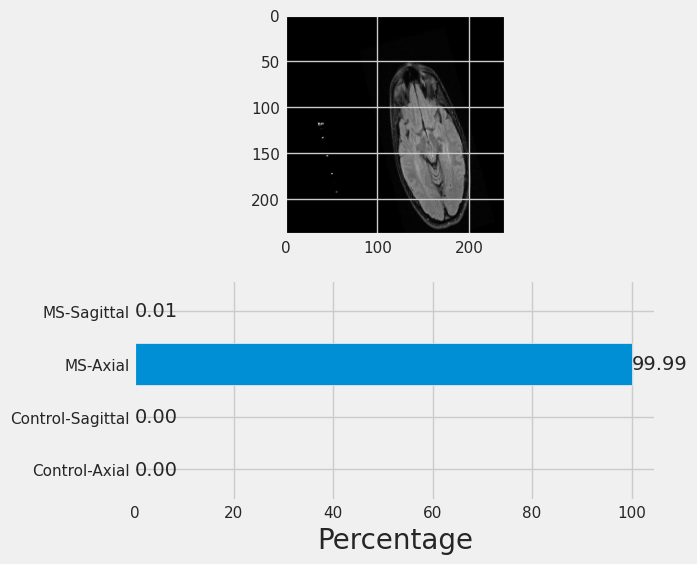

In [69]:
showPredictionStatistics('/kaggle/working/test/MS-Axial/augmented_image_213.png')